In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from scipy import stats

nltk.download('vader_lexicon', quiet=True)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.family'] = 'serif'
print("Environment Ready!")

Environment Ready!


In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

print('Path set. Python will now look in:', os.path.abspath('..'))

# ─────────────────────────────────────────────────────────────
# Import our functions from src/
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

from src.data_loader import load_data, remove_nulls
from src.analysis    import compute_sma, get_daily_return

print('Functions imported successfully!')
print()

Path set. Python will now look in: /home/mine/10 Academy/news-sentiment-analysis
Functions imported successfully!



In [3]:
aapl_df = load_data('../Data/yfinance_data/AAPL.csv')
aapl_df.head()


Loaded 3774 rows from ../Data/yfinance_data/AAPL.csv


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [4]:
news_df = pd.read_csv('../Data/newsData/raw_analyst_ratings.csv')
news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', utc=True)

news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54+00:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20+00:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07+00:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06+00:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59+00:00,A


In [5]:
# Normalize dates to date-only (no time component)
news_df['date'] = pd.to_datetime(news_df['date']).dt.normalize()

print('Date columns normalized.')
print('News date range:', news_df['date'].min().date(), '->', news_df['date'].max().date())

Date columns normalized.
News date range: 2009-02-14 -> 2020-06-11


In [6]:
sia = SentimentIntensityAnalyzer()

def get_vader_compound(text):
    """Return VADER compound score for a text string."""
    if pd.isna(text) or str(text).strip() == '':
        return 0.0
    return sia.polarity_scores(str(text))['compound']

news_df['sentiment_score'] = news_df['headline'].apply(get_vader_compound)

print('Sentiment scores assigned.')
print(news_df[['headline', 'sentiment_score']].head(10).to_string(index=False))

Sentiment scores assigned.
                                                                                                                headline  sentiment_score
                                                                                 Stocks That Hit 52-Week Highs On Friday            0.000
                                                                              Stocks That Hit 52-Week Highs On Wednesday            0.000
                                                                                           71 Biggest Movers From Friday            0.000
                                                                            46 Stocks Moving In Friday's Mid-Day Session            0.000
                                 B of A Securities Maintains Neutral on Agilent Technologies, Raises Price Target to $88            0.296
                                                 CFRA Maintains Hold on Agilent Technologies, Lowers Price Target to $85           -0.128
       

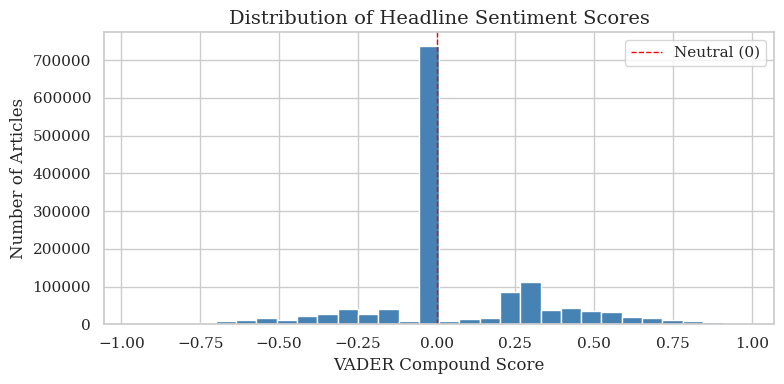

Mean sentiment: 0.0665
Std  sentiment: 0.2714


In [7]:
# Distribution of sentiment scores
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(news_df['sentiment_score'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Neutral (0)')
ax.set_xlabel('VADER Compound Score', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Distribution of Headline Sentiment Scores', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()
print(f"Mean sentiment: {news_df['sentiment_score'].mean():.4f}")
print(f"Std  sentiment: {news_df['sentiment_score'].std():.4f}")